![LeNet-5 Architecture](LeNet_fig.png)

Input → Conv1 → AvgPool → Conv2 → AvgPool → Conv3 → FC1 → FC2 → Output

---
### LeNet-5 Architecture

#### 1. Input Layer
- Size: 32 × 32 × 1
- MNIST images (28×28) are padded to 32×32.

#### 2. C1 — Convolution Layer
- Filters: 6
- Kernel (filter) size: 5×5
- Stride: 1
- Activation: Tanh

**Output size calculation:** $(n-f+1) = (32 - 5 + 1) = 28$

Output shape: $28 × 28 × 6$

#### 3. S2 — Subsampling (Average Pooling)
- Pool size: 2×2
- Stride: 2
- Type: Average Pooling
- Includes trainable scaling and bias

Output: $14 × 14 × 6$

#### 4. C3 — Convolution Layer
- Filters: 16
- Kernel size: 5×5
- Partial connectivity (not fully connected to all previous feature maps)

Output size: $(14 - 5 + 1) = 10$

Output shape: $10 × 10 × 16$

### 5. S4 — Subsampling
- 2×2 Average Pooling

Output: $5 × 5 × 16$

#### 6. C5 — Convolution Layer
- Filters: 120
- Kernel size: 5×5

Since input is 5×5, kernel covers entire feature map.

Output: $1 × 1 × 120$

### 7. F6 — Fully Connected Layer
- 84 neurons
- Activation: Tanh

### 8. Output Layer
- 10 neurons
- Originally used Gaussian RBF
- Modern implementations use Softmax




### Create the Model

In [1]:
import torch.nn as nn

class LeNet5(nn.Module):

    def __init__(self,):
        super().__init__()

        ## Convolutionnal Layer
        self.features = nn.Sequential(
            # C1
            nn.Conv2d(1, 6, kernel_size=5),     # 32x32 → 28x28
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),        # 28x28 → 14x14
            # C3
            nn.Conv2d(6, 16, kernel_size=5),    # 14x14 → 10x10
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2),        # 10x10 → 5x5
            # C5
            nn.Conv2d(16, 120, kernel_size=5),  # 5x5 → 1x1
            nn.Tanh()
        )

        ## Fully Connected Layers
        self.classifier = nn.Sequential(
            nn.Flatten(),          # 120 × 1 × 1 → 120
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [2]:
import torch
import torch.optim as optim
from torchvision import datasets, transforms
import warnings
# warnings.filterwarnings("ignore", category=UserWarning)


# if torch.cuda.is_available():
#     device = torch.device("cuda")
# elif torch.backends.mps.is_available():
#     device = torch.device("mps")
# else:
#     device = torch.device("cpu")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)


Using device: mps


### Download and transform the data

In [3]:
transform = transforms.Compose([
    transforms.Pad(2),      # 28x28 → 32x32
    transforms.ToTensor()
    ])

# Setup training data
train_dataset = datasets.MNIST(root='./data', # location to download data to
                               train=True,    # get training data
                               download=True, # download data if it doesn't exist on disk
                               transform=transform, # transformations on data
                               target_transform=None # you can transform labels as well
                            ) 
# Setup testing data
test_dataset  = datasets.MNIST(root='./data', 
                               train=False,   # get test data
                               download=True, 
                               transform=transform
                            )


In [4]:
# How many samples are there? 
len(train_dataset.data), len(train_dataset.targets), len(test_dataset.data), len(test_dataset.targets)

(60000, 60000, 10000, 10000)

In [5]:
train_dataset, len(train_dataset)

(Dataset MNIST
     Number of datapoints: 60000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: Compose(
                Pad(padding=2, fill=0, padding_mode=constant)
                ToTensor()
            ),
 60000)

In [6]:
train_dataset.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [7]:
train_dataset.data

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [8]:
train_dataset.data.shape

torch.Size([60000, 28, 28])

In [9]:
train_dataset.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [10]:
train_dataset.transform

Compose(
    Pad(padding=2, fill=0, padding_mode=constant)
    ToTensor()
)

In [11]:
image, label = train_dataset[0]

print(type(image)) # Image → Tensor
print(image.shape) # Shape → [1, 32, 32]
print(label)       # Label → integer (0–9)

<class 'torch.Tensor'>
torch.Size([1, 32, 32])
5


In [12]:
print(image.shape)
print(train_dataset.data[0].shape)

torch.Size([1, 32, 32])
torch.Size([28, 28])


In [13]:
# Transforms Are Applied On-The-Fly
# train_dataset.data is the raw stored dataset.

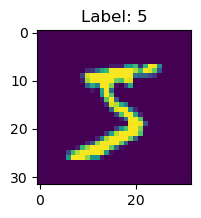

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,2))
plt.imshow(image.squeeze())  # image shape is [1, 28, 28] (color channels, height, width)
plt.title(f"Label: {label}")
plt.show()


Text(0.5, 1.0, 'Label: 5')

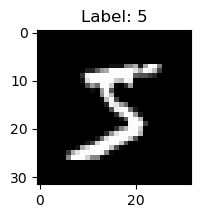

In [15]:
plt.figure(figsize=(3,2))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")

In [16]:
len(train_dataset.classes)

10

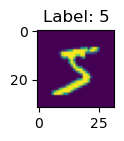

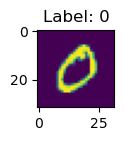

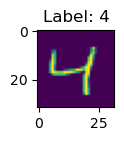

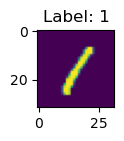

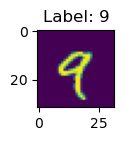

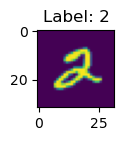

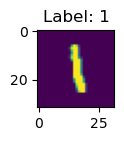

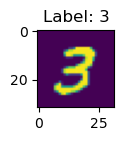

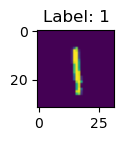

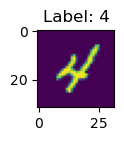

In [17]:
for idx in range(len(train_dataset.classes)):
    image, label = train_dataset[idx]
    # print(idx, label)
    plt.figure(figsize=(2,1))
    plt.imshow(image.squeeze())
    plt.title(f"Label: {label}")

### Prepare The DataLoader

In [18]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32


train_loader = DataLoader(train_dataset,         # dataset to turn into iterable
                          batch_size=BATCH_SIZE, # number of datapoints or samples per batch 
                          shuffle=True           # shuffle data every epoch
                        )

test_loader  = DataLoader(test_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=False          # don't necessarily have to shuffle the testing data
                        )

print(f"Dataloaders: {train_loader, test_loader}") 
print(f"Length of train dataloader: {len(train_loader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_loader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x1654edba0>, <torch.utils.data.dataloader.DataLoader object at 0x165538070>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [19]:
# Total batches = 1875
# Each batch contains = 32 samples

In [20]:
len(train_loader), len(train_loader)*BATCH_SIZE

(1875, 60000)

In [21]:
# Check out the training dataloader

images, labels = next(iter(train_loader)) 
print(images.shape)
print(labels.shape)

torch.Size([32, 1, 32, 32])
torch.Size([32])


In [22]:
## iter(train_loader) >> This creates an iterator object.
## next(iterator) >> Gives the next batch.
## next(iter(train_loader)) >> Start iterating and give me the first batch.

# >> Output <<
# 32 images per batch
# 1 channel
# 32×32 pixels
# 32 labels

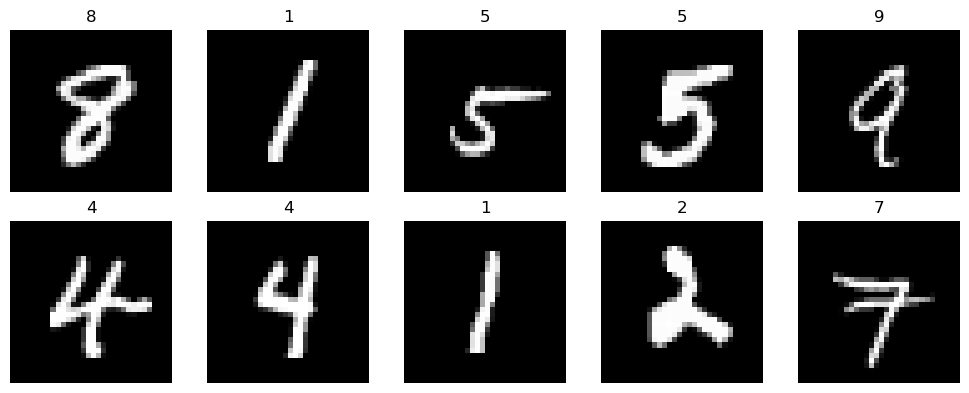

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(labels[i].item())
    ax.axis("off")

plt.tight_layout()
plt.show()

In [24]:
torch.manual_seed(123)

model = LeNet5().to(device)   # send the model to device
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(), lr=1e-3)

In [25]:
model.parameters()

<generator object Module.parameters at 0x168591d20>

In [26]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
LeNet5                                   --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       156
│    └─Tanh: 2-2                         --
│    └─AvgPool2d: 2-3                    --
│    └─Conv2d: 2-4                       2,416
│    └─Tanh: 2-5                         --
│    └─AvgPool2d: 2-6                    --
│    └─Conv2d: 2-7                       48,120
│    └─Tanh: 2-8                         --
├─Sequential: 1-2                        --
│    └─Flatten: 2-9                      --
│    └─Linear: 2-10                      10,164
│    └─Tanh: 2-11                        --
│    └─Linear: 2-12                      850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0

In [27]:
model.eval()

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): Tanh()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=84, bias=True)
    (2): Tanh()
    (3): Linear(in_features=84, out_features=10, bias=True)
  )
)

### Training and testing 

In [28]:
# Measure time
from timeit import default_timer as timer
from tqdm import tqdm

train_time_start = timer()

losses = [] 
epochs = 5

for epoch in tqdm(range(epochs)):

    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        # Send data to device
        images, labels = images.to(device), labels.to(device)
        # Optimizer zero grad
        optimizer.zero_grad()
        # Forward pass
        outputs = model(images)
        # Calculate loss
        loss = criterion(outputs, labels)
        # Loss backward
        loss.backward()
        # Optimizer step
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

    losses.append(running_loss/len(train_loader))

train_time_end = timer()

total_time = train_time_end - train_time_start
print(f"Train time on {device}: {total_time:.3f} seconds")

 20%|██        | 1/5 [00:12<00:51, 12.95s/it]

Epoch [1/5], Loss: 0.2419


 40%|████      | 2/5 [00:27<00:41, 13.81s/it]

Epoch [2/5], Loss: 0.0826


 60%|██████    | 3/5 [00:40<00:27, 13.57s/it]

Epoch [3/5], Loss: 0.0577


 80%|████████  | 4/5 [00:53<00:13, 13.32s/it]

Epoch [4/5], Loss: 0.0473


100%|██████████| 5/5 [01:06<00:00, 13.28s/it]

Epoch [5/5], Loss: 0.0374
Train time on mps: 66.397 seconds


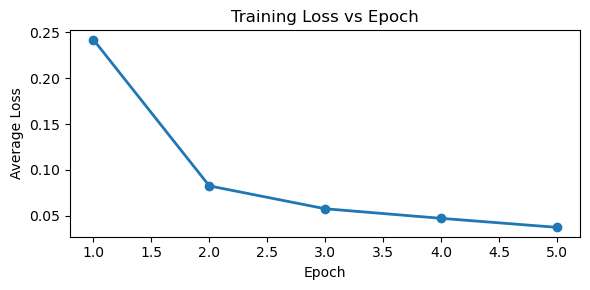

In [29]:
plt.figure(figsize=(6, 3))
plt.plot(range(1, epochs+1), losses, 'o-', linewidth=2, markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss vs Epoch')
plt.tight_layout()
plt.show()

In [30]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 98.37%
